# What is our task?

We need to predicts taxi fares based on historical New York taxi fare data.

# What we have?

Each row in the taxi-fare-train.csv data set contains details of trips made by a taxi.

The taxi-fare-train.csv data set The provided data set contains the following columns:
- vendor_id: The ID of the taxi vendor is a feature.
- rate_code: The rate type of the taxi trip is a feature.
- passenger_count: The number of passengers on the trip is a feature.
- trip_time_in_secs: The amount of time the trip took. You want to predict the fare of the trip before the trip is completed. At that moment you don't know how long the trip would take. Thus, the trip time is not a feature and you'll exclude this column from the model.
- trip_distance: The distance of the trip is a feature.
- payment_type: The payment method (cash or credit card) is a feature.
- fare_amount: The total taxi fare paid is the label.

The label is the column you want to predict. When performing a regression task, the goal is to predict a numerical value. In this price prediction scenario, the cost of a taxi ride is being predicted. Therefore, the fare_amount is the label. The identified features are the inputs you give the model to predict the label . In this case, the rest of the columns with the exception of trip_time_in_secs are used as features or inputs to predict the fare amount.

# How to Evaluate?

Our task is a regression task so we'll use Mean Absolute Error, Mean Square Error and R^2 score.

# Before we begin

In [42]:
! wget https://raw.githubusercontent.com/dotnet/machinelearning-samples/refs/heads/main/datasets/taxi-fare-train.csv -O small-taxi-fare-train.csv
# ! wget https://raw.githubusercontent.com/dotnet/machinelearning/main/test/data/taxi-fare-train.csv -O larg-taxi-fare-train.csv

--2026-01-27 07:13:22--  https://raw.githubusercontent.com/dotnet/machinelearning-samples/refs/heads/main/datasets/taxi-fare-train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2409590 (2.3M) [text/plain]
Saving to: ‘small-taxi-fare-train.csv’

small-taxi-fare-tra 100%[===================>]   2.30M  --.-KB/s    in 0.04s   

2026-01-27 07:13:22 (57.9 MB/s) - ‘small-taxi-fare-train.csv’ saved [2409590/2409590]



# Hands on CODE!

## Import needed libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

## Read and Understand data

In [44]:
df = pd.read_csv('small-taxi-fare-train.csv')
df.sample(5)

,vendor_id,rate_code,passenger_count,trip_time_in_secs,trip_distance,payment_type,fare_amount
54251,VTS,1,5,1200,12.29,CSH,34.0
15227,VTS,1,5,720,2.03,CSH,10.5
79143,CMT,1,1,801,4.90,CRD,16.5
12780,VTS,2,1,1920,18.25,CSH,52.0
45460,CMT,1,1,366,0.90,CSH,6.0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   vendor_id          100000 non-null  object 
 1   rate_code          100000 non-null  int64  
 2   passenger_count    100000 non-null  int64  
 3   trip_time_in_secs  100000 non-null  int64  
 4   trip_distance      100000 non-null  float64
 5   payment_type       100000 non-null  object 
 6   fare_amount        100000 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.3+ MB


In [46]:
df.trip_time_in_secs = df.trip_time_in_secs.astype('float64')

`trip_time_in_secs` is a numerical feature, i need to change it's type.

## Analyze ...

### NaN fields

In [47]:
df.isna().sum()

,0
vendor_id,0
rate_code,0
passenger_count,0
trip_time_in_secs,0
trip_distance,0
payment_type,0
fare_amount,0


No missing Values? ok ...

### Numerical Features

In [48]:
df_numbers = df.select_dtypes(include='float64')
df_numbers.columns

Index(['trip_time_in_secs', 'trip_distance', 'fare_amount'], dtype='object')

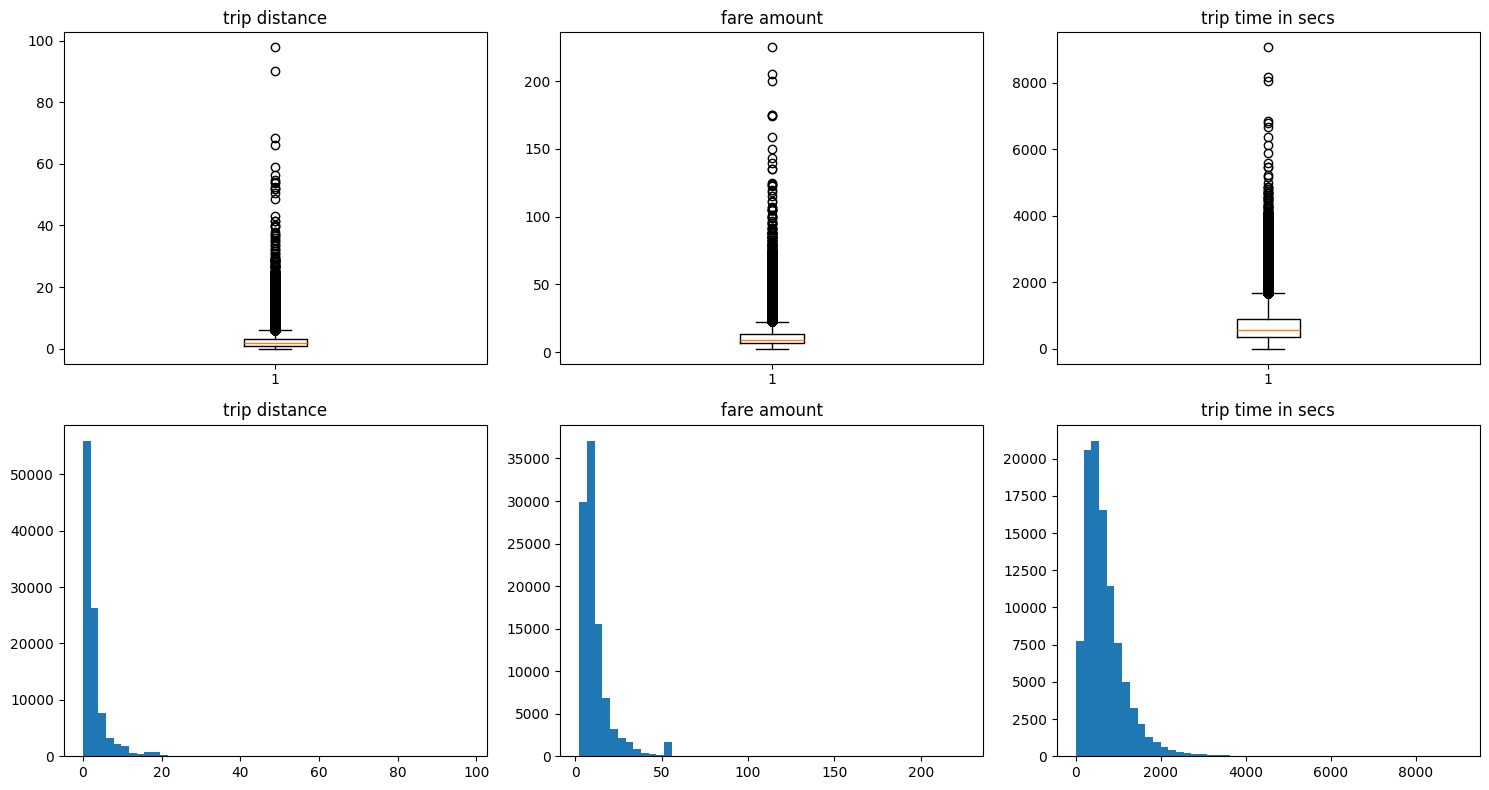

In [49]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

axes[0, 0].boxplot(x=df_numbers.trip_distance)
axes[0, 0].set_title('trip distance')
axes[0, 1].boxplot(x=df_numbers.fare_amount)
axes[0, 1].set_title('fare amount')

axes[1, 0].hist(df_numbers.trip_distance, bins=50)
axes[1, 0].set_title('trip distance')
axes[1, 1].hist(df_numbers.fare_amount, bins=50)
axes[1, 1].set_title('fare amount')

axes[0, 2].boxplot(df_numbers.trip_time_in_secs)
axes[0, 2].set_title('trip time in secs')
axes[1, 2].hist(df_numbers.trip_time_in_secs, bins=50)
axes[1, 2].set_title('trip time in secs')

plt.tight_layout()
plt.show()

In [50]:
df_numbers.describe().T

,count,mean,std,min,25%,50%,75%,max
trip_time_in_secs,100000.0,682.633130,487.959329,0.0,360.00,554.00,883.00,9060.0
trip_distance,100000.0,2.796149,3.318861,0.0,1.03,1.72,3.09,97.8
fare_amount,100000.0,11.648603,9.484526,2.5,6.50,9.00,13.00,225.0


Well Well Well ... as we can see we've got outliers in these features.

In [51]:
(df.trip_distance == 0).sum()

np.int64(463)

Some taxis take passengers for 0 km! this shall be fixed.

In [52]:
(df.trip_time_in_secs == 0).sum()

np.int64(254)

Some taxis take 0 second for taking passengers! maybe the passenger request was canceled ... whatever i shall fix this too.

### Categorical Features

In [53]:
df_cat = df.select_dtypes(exclude='float64')
df_cat.columns

Index(['vendor_id', 'rate_code', 'passenger_count', 'payment_type'], dtype='object')

In [54]:
df_cat.passenger_count.value_counts()

,count
passenger_count,
1,68684
2,14011
5,6871
6,5494
3,3410
4,1529
0,1


Most of times taxis only got 1 passenger, and some times they got 6! But why are there 0 passenger? what dose it mean? is this kinda NaN value? i'll fix this ...

In [55]:
df_cat.rate_code.value_counts()

,count
rate_code,
1,97880
2,1584
5,273
4,149
3,113
0,1


In [56]:
df_cat.payment_type.value_counts()

,count
payment_type,
CRD,52222
CSH,47614
NOC,88
UNK,57
DIS,19


There are 57 Unknown payment type.

In [57]:
df_cat.vendor_id.value_counts()

,count
vendor_id,
VTS,62222
CMT,37778


### Correlation

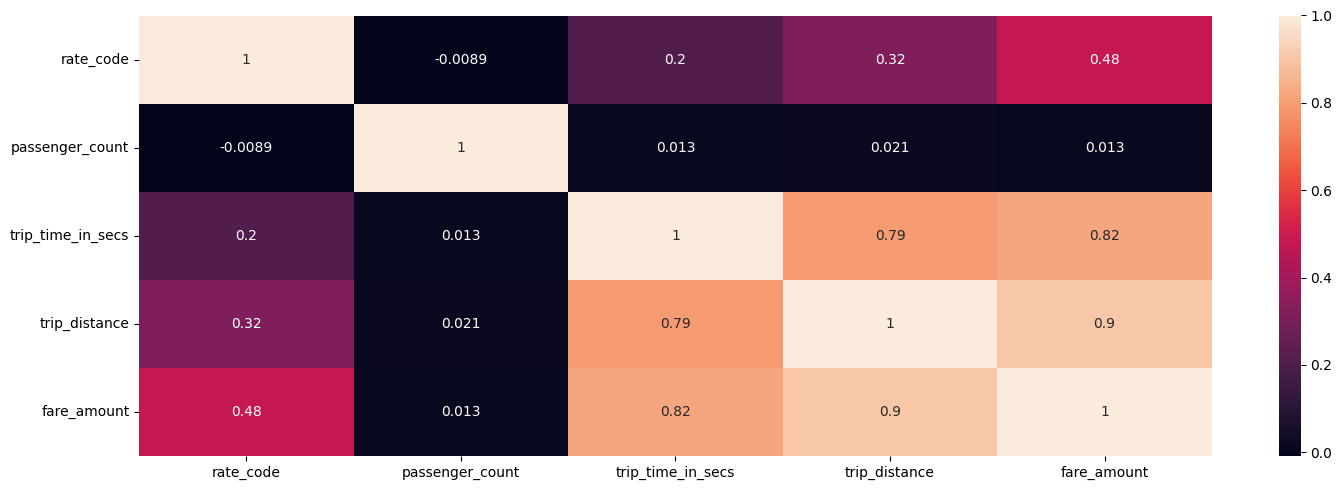

In [58]:
plt.figure(figsize=(15, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.tight_layout()
plt.show()

There is a strong correlation with ...
- `trip_distance` with `trip_time_in_secs` features (79%) ofcourse if you have a 1km trip you'll be faster in there than a 10km trip ...
- `fare_amount` with `trip_distance` features (90%) if you want to travel more distance you shall pay more ...
- and others ...

## Feature Engineering

I want to convert `trip_time_in_secs` to `trip_time_in_mins` tho it's easy to understand.

In [59]:
df['trip_time_in_mins'] = df['trip_time_in_secs'] / 60

In [60]:
df = df.drop(columns=['trip_time_in_secs'])

In [61]:
df['trip_time_in_mins'].sort_values()

,trip_time_in_mins
98323,0.00
97136,0.00
58675,0.00
97135,0.00
13340,0.00
...,...
71084,113.05
54211,114.00
97976,134.00
66275,136.10


## Preprocess

### Remove outliers

In [62]:
def remove_feature_outliers_iqr(dataset: pd.DataFrame, name: str):
    Q1 = dataset[name].quantile(0.25)
    Q2 = dataset[name].quantile(0.50)
    Q3 = dataset[name].quantile(0.75)

    IQR = Q3 - Q1

    threshold = 3
    lowerBound = Q1 - threshold * IQR
    upperBound = Q3 + threshold * IQR

    print('There are', (dataset[name] < lowerBound).sum() + (dataset[name] > upperBound).sum(), 'outliers in feature', name)

    return dataset[(dataset[name] >= lowerBound) & (dataset[name] <= upperBound)]

In [63]:
len(remove_feature_outliers_iqr(df, 'trip_distance')), len(remove_feature_outliers_iqr(df, 'trip_time_in_mins'))

There are 5241 outliers in feature trip_distance
There are 1018 outliers in feature trip_time_in_mins


(94759, 98982)

In [64]:
# df = remove_feature_outliers_iqr(df, 'trip_distance')
# df = remove_feature_outliers_iqr(df, 'trip_time_in_mins')

We can do this using *logarithn* or *IQR*. I also chose to use RobustScaler for handeling outliers and scaling datas.

### Remove unusual rows and columns

In [65]:
# df = df.drop(df[df['passenger_count'] == 6].index)
df = df.drop(df[df['passenger_count'] == 0].index)
df = df.drop(df[df['rate_code'] == 0].index)
df = df.drop(df[df['rate_code'] == 6].index)
df = df.drop(df[df['payment_type'] == 'UNK'].index)
df = df.drop(columns=['vendor_id'])

### Setup Preprocess Pipeline

In [66]:
df.columns

Index(['rate_code', 'passenger_count', 'trip_distance', 'payment_type',
       'fare_amount', 'trip_time_in_mins'],
      dtype='object')

In [67]:
df_cat = ['payment_type']
df_numeric = ['trip_distance', 'trip_time_in_mins']

#### numeric features

I want to fill 0.0 values with nearest neighbor + i want to use Robust Scaler to scale data tho to outlier treatment.

In [68]:
numeric_transformer = sklearn.pipeline.Pipeline(
    steps=[
        ('imputer', sklearn.impute.KNNImputer(missing_values=0.0)),
        ('scaler', sklearn.preprocessing.RobustScaler())
    ]
)

#### categorical features

I want to One-Hot feature `payment_type` and `vendor_id`

In [69]:
categorical_transfotmer = sklearn.pipeline.Pipeline(
    steps=[
        ('onehot', sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

#### finall ...

In [70]:
df_cat, df_numeric

(['payment_type'], ['trip_distance', 'trip_time_in_mins'])

In [71]:
preprocessor = sklearn.compose.ColumnTransformer(
    transformers=[
        ('num_t', numeric_transformer, df_numeric),
        ('cat_t', categorical_transfotmer, df_cat)
    ]
)

## Model design

### Create train test

In [72]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=123)

### Setup Models + Pipeline and fit ...

In [73]:
sgdRegressor_model_pipeline = sklearn.pipeline.Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('regressor', sklearn.linear_model.SGDRegressor())
    ]
)

sgdRegressor_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_t',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(missing_values=0.0)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['trip_distance',
                                                   'trip_time_in_mins']),
                                                 ('cat_t',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['payment_type'])])),
                ('regressor', SGDRegressor())])

In [74]:
lasso_model_pipeline = sklearn.pipeline.Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('regressor', sklearn.linear_model.Lasso())
    ]
)

lasso_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_t',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(missing_values=0.0)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['trip_distance',
                                                   'trip_time_in_mins']),
                                                 ('cat_t',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['payment_type'])])),
                ('regressor', Lasso())])

In [75]:
rfr_model_pipeline = sklearn.pipeline.Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('regressor', sklearn.ensemble.RandomForestRegressor())
    ]
)

rfr_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_t',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(missing_values=0.0)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['trip_distance',
                                                   'trip_time_in_mins']),
                                                 ('cat_t',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['payment_type'])])),
                ('regressor', RandomForestRegressor())])

In [76]:
ridge_model_pipeline = sklearn.pipeline.Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('regressor', sklearn.linear_model.Ridge())
    ]
)

ridge_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_t',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(missing_values=0.0)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['trip_distance',
                                                   'trip_time_in_mins']),
                                                 ('cat_t',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['payment_type'])])),
                ('regressor', Ridge())])

## Evaluate models

In [77]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
    mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
    r2 = sklearn.metrics.r2_score(y_test, y_pred)
    return {'mae': mae, 'mse': mse, 'r2': r2}

In [78]:
print('SGDRegressor', evaluate_model(sgdRegressor_model_pipeline, X_test, y_test))
print('Lasso', evaluate_model(lasso_model_pipeline, X_test, y_test))
print('RandomForest', evaluate_model(rfr_model_pipeline, X_test, y_test))
print('Ridge', evaluate_model(ridge_model_pipeline, X_test, y_test))

SGDRegressor {'mae': 0.7965233005205916, 'mse': 13.752031812763663, 'r2': 0.8523230605821441}
Lasso {'mae': 1.297454401396307, 'mse': 15.17078003501062, 'r2': 0.8370877558563729}
RandomForest {'mae': 0.6233897596803702, 'mse': 10.517889141655616, 'r2': 0.8870530770489939}
Ridge {'mae': 0.7198759832342632, 'mse': 13.54616783839719, 'r2': 0.8545337420352381}


## Saving best model with skl2onnx

In [88]:
! pip install skl2onnx skl2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 136.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.0 MB/s eta 0:00:00


In [85]:
from skl2onnx import to_onnx
from skl2onnx.common.data_types import Int64TensorType, FloatTensorType, StringTensorType

# we need to turn our features type into ONNX types
initial_types = []
for col_name, dtype in X_train.dtypes.items():
    if dtype == 'int64':
        initial_types.append((col_name, Int64TensorType([None, 1])))
          # None is for batch size:
          #   this means that the model can accept a variable number of samples (rows) at inference time.

          # 1 is for Feature Dimension:
          #   it indicates that each individual feature (like rate_code or trip_distance) is treated as a
          #   single scalar value within each sample.

          # [None, 1] means take an item of each feature, which means it takes a row of dataset
    elif dtype == 'float64':
        initial_types.append((col_name, FloatTensorType([None, 1])))
    elif dtype == 'object':
        initial_types.append((col_name, StringTensorType([None, 1])))

# now we are going to save best model into Disk
onx = to_onnx(rfr_model_pipeline, initial_types=initial_types, target_opset=18)
with open("rfr_model_pipeline.onnx", "wb") as f:
    f.write(onx.SerializeToString())

## Load model with onnxruntime

In [89]:
! pip install onnxruntime

In [102]:
from onnxruntime import InferenceSession
import numpy as np

# first load model into RAM
with open("rfr_model_pipeline.onnx", "rb") as f:
    onx = f.read()
sess = InferenceSession(onx, providers=["CPUExecutionProvider"])

# We need to set input types of model inputs which we are loading
onnx_inputs = {}
for col_name in sess.get_inputs():
    # The ONNX model was created using initial_types with [None, 1] shape for
    # each feature (if you forget, read `save model` cell again). We need to
    # ensure the input data also has this shape.
    if X_test[col_name.name].dtype == 'int64':
        onnx_inputs[col_name.name] = X_test[col_name.name].values.reshape(-1, 1).astype(np.int64)
    elif X_test[col_name.name].dtype == 'float64':
        onnx_inputs[col_name.name] = X_test[col_name.name].values.reshape(-1, 1).astype(np.float32)
    elif X_test[col_name.name].dtype == 'object':
        # For string type, ensure it's an object array of strings
        onnx_inputs[col_name.name] = X_test[col_name.name].values.reshape(-1, 1).astype(object)
    else:
        raise TypeError(f"Unsupported data type for ONNX inference: {X_test[col_name.name].dtype} for column {col_name.name}")

# Perform inference
pred_ort = sess.run(None, onnx_inputs)[0]

# Optionally, you can print some predictions to verify
print(f"Predictions shape: {pred_ort.shape}")
print(f"First 5 ONNX predictions: {pred_ort[:5].flatten()}")
print(f"First 5 actual fare amounts: {y_test.iloc[:5].values}")

Predictions shape: (19989, 1)
First 5 ONNX predictions: [ 7.576418   9.105218   5.000001  17.125008   4.0930443]
First 5 actual fare amounts: [ 7.5  9.   5.  17.5  4. ]
